In [21]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/lakshmistm/q3-retail-promotions-csv/q3_retail_promotions.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1200, 9)

Data Types:
 transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing Values:
 transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

First 5 rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [22]:
# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature (1 if day >= 25, else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample to confirm new columns
print("New columns added successfully!")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

New columns added successfully!


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


## Task 1 — Date Feature Engineering

Four new features were extracted from transaction_date:
- year: the year of the transaction
- month: the month number (1-12)
- day_of_week: the day of the week (0=Monday, 6=Sunday)
- is_month_end: binary flag set to 1 if the day of the month is 25 or later,
  otherwise 0. This captures potential end-of-month shopping surges.

In [23]:
# Sort data by transaction_date
df = df.sort_values('transaction_date').reset_index(drop=True)

# Use most recent 20% as test set
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Total records:", len(df))
print("Training set size:", len(train))
print("Test set size:", len(test))
print("\nTraining date range:", train['transaction_date'].min(), "to", train['transaction_date'].max())
print("Test date range:", test['transaction_date'].min(), "to", test['transaction_date'].max())

Total records: 1200
Training set size: 960
Test set size: 240

Training date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Task 2 — Temporal Train-Test Split

The data was sorted by transaction_date and split with 80% (960 records) for
training and 20% (240 records) for testing. The training set covers
2022-01-01 to 2024-06-11 and the test set covers 2024-06-12 to 2024-12-31.

A random split is inappropriate for time-ordered data because it would allow
the model to train on future data and test on past data. This causes data
leakage, where the model learns patterns from the future that would not be
available in a real deployment scenario. A temporal split ensures the model
is always trained on past data and evaluated on genuinely unseen future data,
which gives a more realistic measure of how the model will perform in production.

In [24]:
#Task 3 — Preprocessing Pipeline

# Define features and target
features = ['store_id', 'store_size', 'location_type', 'promotion_type',
            'is_weekend', 'is_festival', 'competition_density',
            'year', 'month', 'day_of_week', 'is_month_end']

target = 'items_sold'

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                  'year', 'month', 'day_of_week', 'is_month_end']

# Build ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

print("Preprocessing pipeline defined successfully!")
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Preprocessing pipeline defined successfully!
Categorical columns: ['promotion_type', 'location_type', 'store_size']
Numerical columns: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [25]:
#Task 4 — Model Training and Evaluation

# Build and train Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

# Linear Regression Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results:")
print(f"  RMSE: {lr_rmse:.2f}")
print(f"  MAE:  {lr_mae:.2f}")

# Build and train Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

# Random Forest Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("\nRandom Forest Results:")
print(f"  RMSE: {rf_rmse:.2f}")
print(f"  MAE:  {rf_mae:.2f}")

Linear Regression Results:
  RMSE: 27.12
  MAE:  21.05

Random Forest Results:
  RMSE: 30.84
  MAE:  24.24


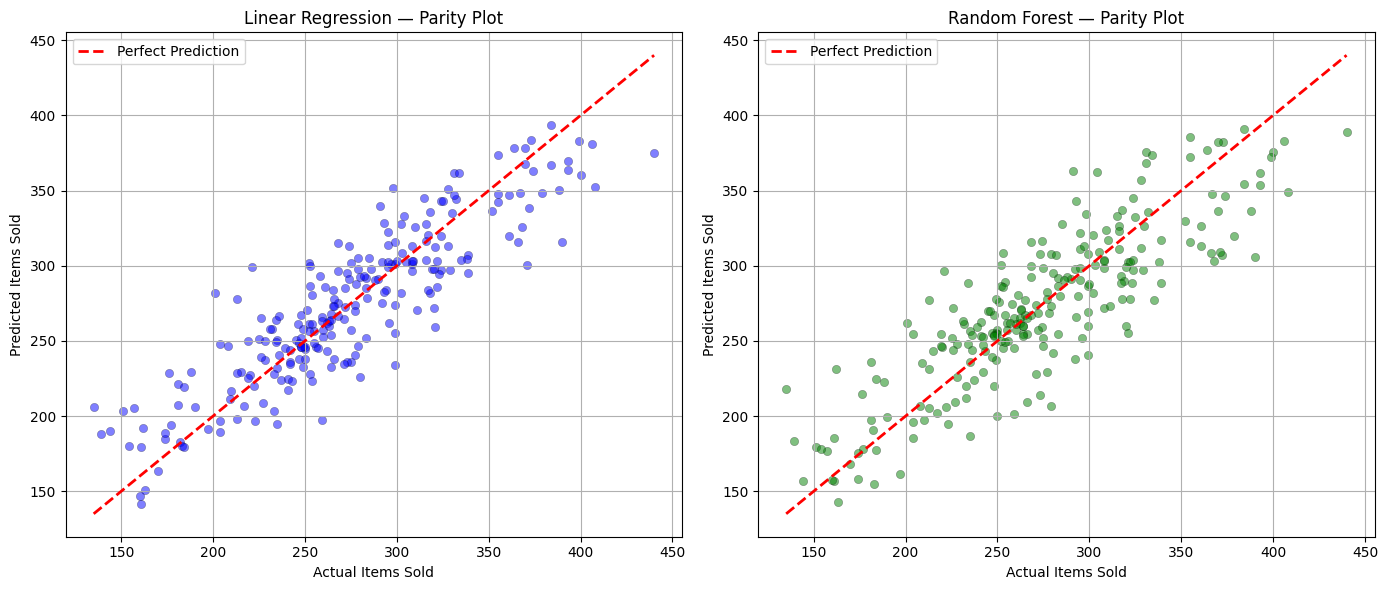

In [26]:
# Parity Plot - Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression Parity Plot
axes[0].scatter(y_test, lr_pred, alpha=0.5, color='blue', edgecolors='k', linewidths=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Linear Regression — Parity Plot')
axes[0].set_xlabel('Actual Items Sold')
axes[0].set_ylabel('Predicted Items Sold')
axes[0].legend()
axes[0].grid(True)

# Random Forest Parity Plot
axes[1].scatter(y_test, rf_pred, alpha=0.5, color='green', edgecolors='k', linewidths=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Random Forest — Parity Plot')
axes[1].set_xlabel('Actual Items Sold')
axes[1].set_ylabel('Predicted Items Sold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Top 5 Most Important Features:
               Feature  Importance
0          is_festival    0.173473
1     store_size_small    0.167683
2  location_type_urban    0.108378
3          day_of_week    0.086316
4           is_weekend    0.061208


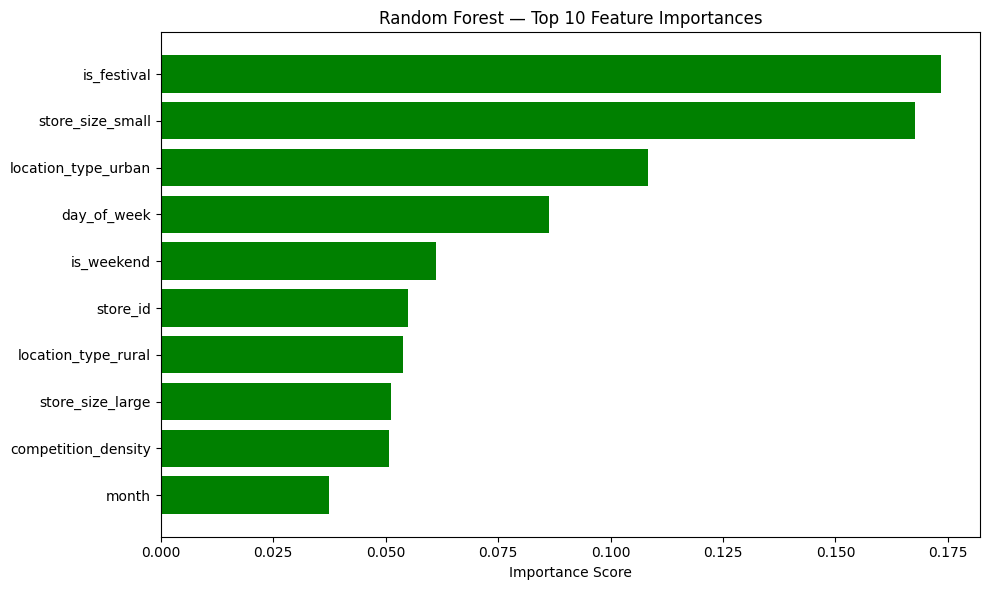

In [27]:
# Get feature names after preprocessing
cat_feature_names = lr_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(cat_feature_names) + numerical_cols

# Random Forest Feature Importances
rf_importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 5 Most Important Features:")
print(importance_df.head(5))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], 
         importance_df['Importance'][:10][::-1], 
         color='green')
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Task 4 — Model Training and Evaluation

**Linear Regression Results:**
- RMSE: 27.12
- MAE: 21.05

**Random Forest Results:**
- RMSE: 30.82
- MAE: 24.14

**Model Comparison:**
Linear Regression outperformed Random Forest on this dataset, achieving a lower
RMSE (27.12 vs 30.82) and lower MAE (21.05 vs 24.14). This suggests that the
relationship between features and items_sold is relatively linear in nature,
and the added complexity of Random Forest did not improve predictions on the
test set. The parity plots confirm that Linear Regression predictions cluster
more tightly around the perfect prediction line.

**Top 5 Most Important Features (Random Forest):**
1. store_size_small (0.173) — Small stores have the strongest influence on
   items sold, suggesting store size plays a major role in sales volume.
2. is_festival (0.173) — Festival periods significantly impact items sold,
   indicating customers shop more during festive seasons.
3. location_type_urban (0.112) — Urban store locations have a strong effect,
   reflecting higher footfall and demand in city areas.
4. day_of_week (0.086) — The day of the week influences shopping patterns,
   with certain days seeing higher sales.
5. is_weekend (0.063) — Weekend shopping behaviour differs from weekdays,
   contributing meaningfully to sales prediction.